In [2]:
%cd ..
# !dir 
import tangramlit as tg

C:\Users\enric\tangram\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\enric\tangram


C:\Users\enric\tangram\.venv\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [3]:

import scanpy as sc
# import squidpy as sq

Retrieve true file path in drive through link:

In [3]:
!uv pip install winshell

Audited 1 package in 146ms


In [4]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")

Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


In [10]:
%cd H:/Il mio Drive/

H:\Il mio Drive


In [ ]:
!dir /a

# Data loading

In [5]:
## Load pre-processed datasets
path = "H:/Il mio Drive"
adata_sc = sc.read_h5ad(path + "/data_tangram/counts100k_filt_pp_train_genes.h5ad")
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe', 'sparsity'
    uns: 'hvg', 'neighbors', 'pca', 'training_genes', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
adata_st = sc.read_h5ad(path + "/data_tangram/slice200_pp.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [18]:
'spatial_connectivities' not in adata_st.obsp.keys()

False

In [7]:
ad_map, _, _ = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='vanilla',
    num_epochs=300,
    lambda_d=1,
    lambda_g1=0.5,
    lambda_g2=0.5,
    lambda_r=0.0003,
    lambda_l1=0.01,
    lambda_l2=0.01,
    #lambda_count=0.005,
    #lambda_f_reg=0.01,
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 164 M  | n/a  
---------------------------------------------------------
164 M     Trainable params
0         Non-trainable params
164 M     Total params
659.839   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


`Trainer.fit` stopped: `max_epochs=300` reached.


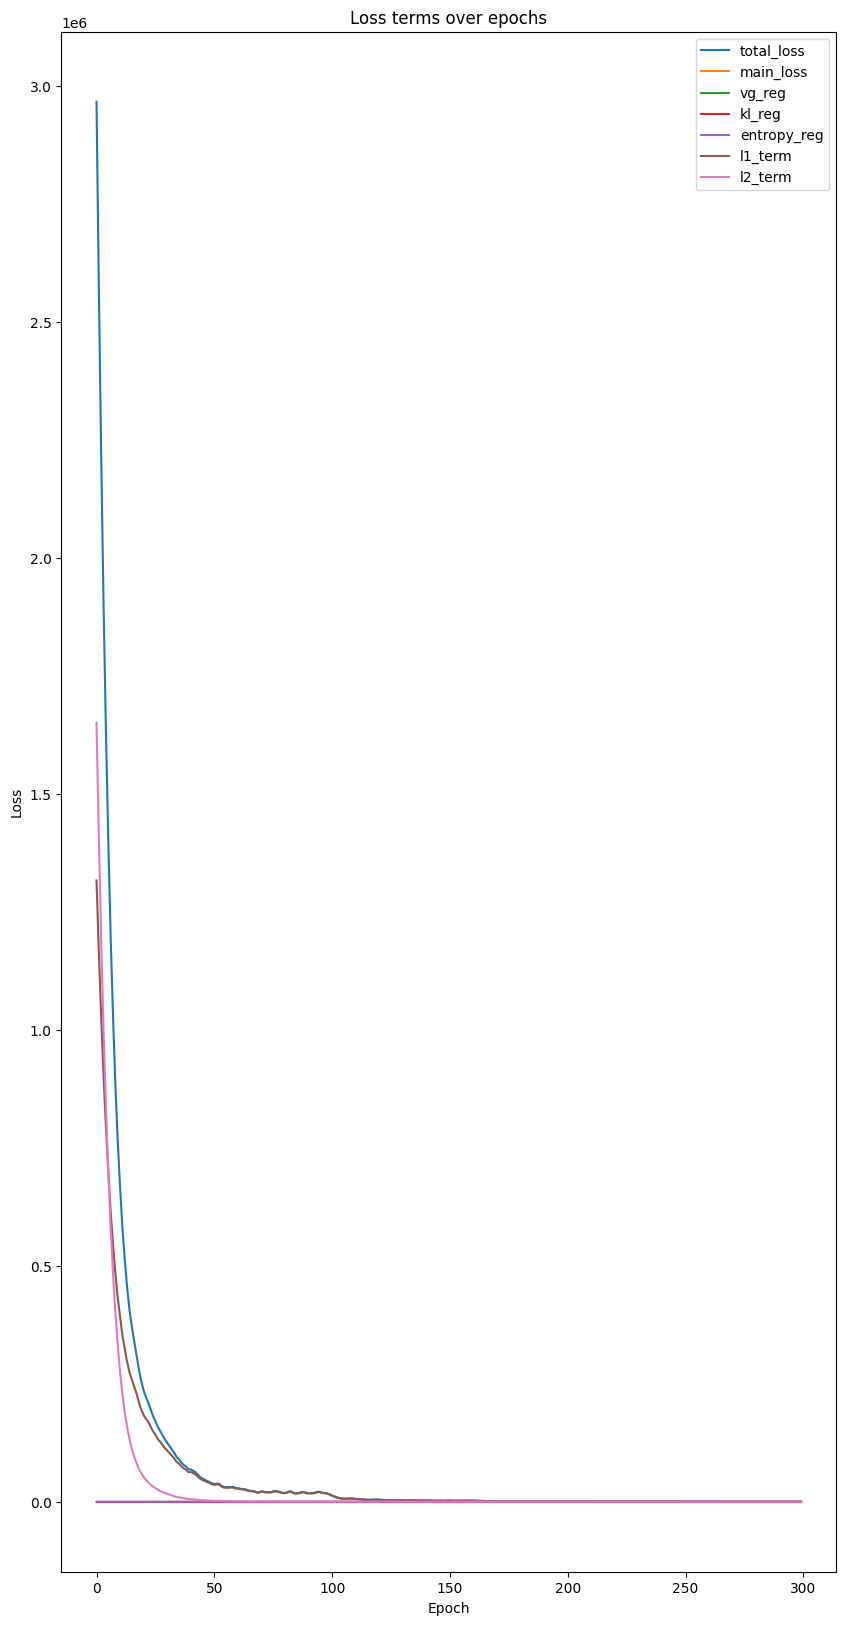

In [10]:
# Plot loss terms
tg.plot_loss_terms(adata_map=ad_map[0], log_scale=False)

This is the unconstrained optimizer with some slighlty tuned $\lambda$s. The optmization seems to settle after $\approx 100$ epochs.

In [7]:
ad_map_filt, mapper_filt, datamodule_filt = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='filter',
    num_epochs=3,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0.0003,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=0.005,
    lambda_f_reg=0.01,
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


`Trainer.fit` stopped: `max_epochs=3` reached.


In [16]:
mapper_filt.hparams

"ct_encode":              None
"lambda_count":           0.005
"lambda_ct_islands":      0
"lambda_d":               1
"lambda_f_reg":           0.01
"lambda_g1":              1
"lambda_g2":              1
"lambda_geary":           0
"lambda_getis_ord":       0
"lambda_l1":              0
"lambda_l2":              0
"lambda_moran":           0
"lambda_neighborhood_g1": 0
"lambda_r":               0.0003
"lambda_sparsity_g1":     0
"learning_rate":          0.1
"mode":                   filter
"neighborhood_filter":    None
"num_epochs":             1000
"random_state":           42
"spatial_weights":        None
"target_count":           2133
"voxel_weights":          None

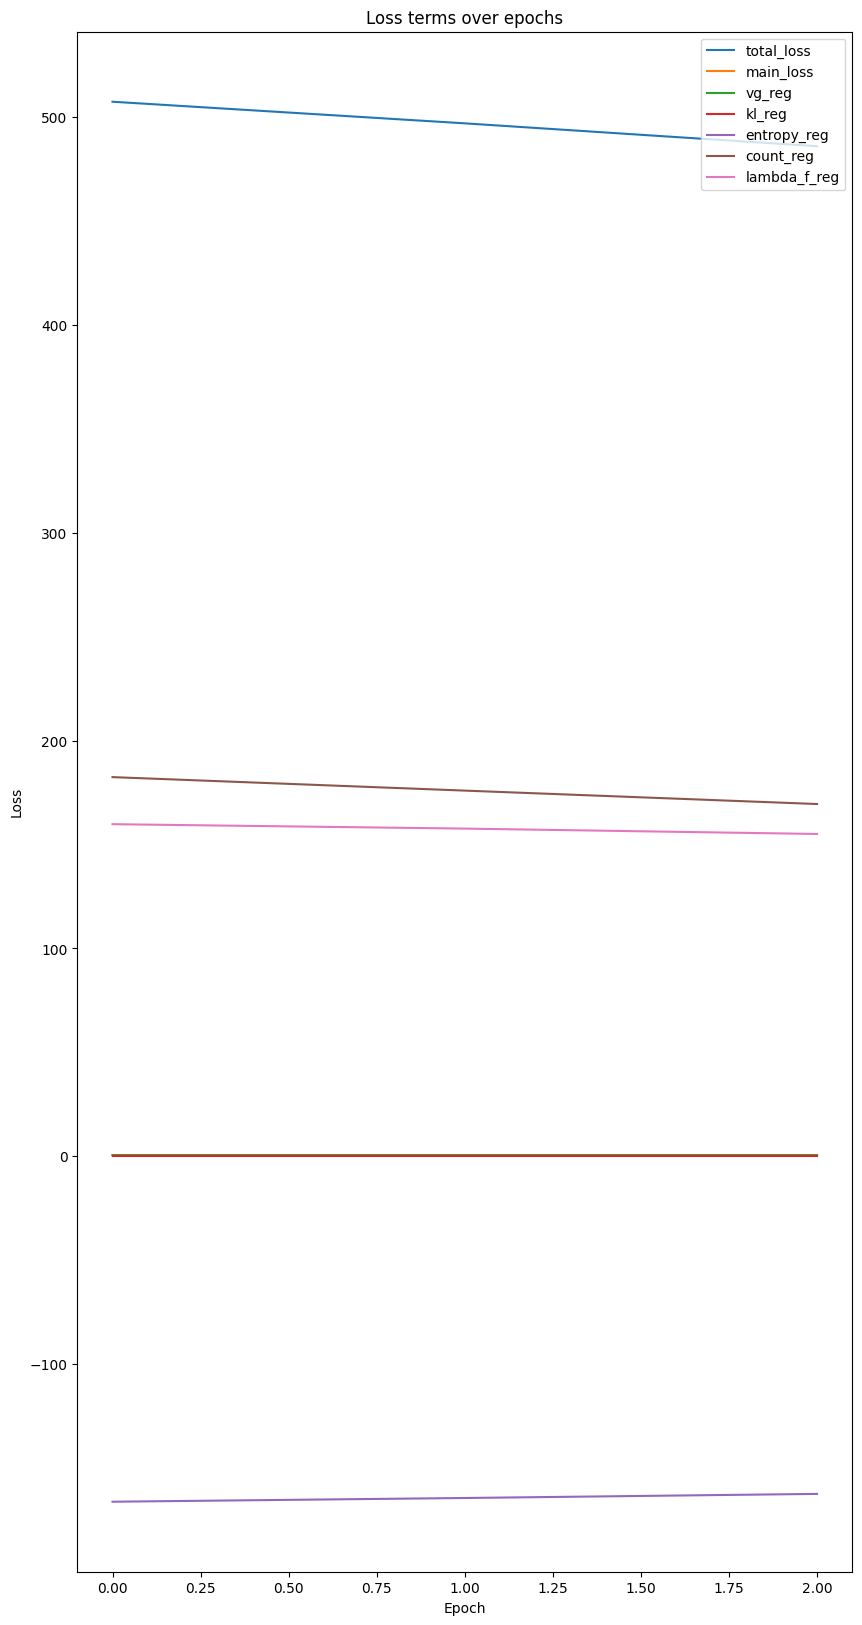

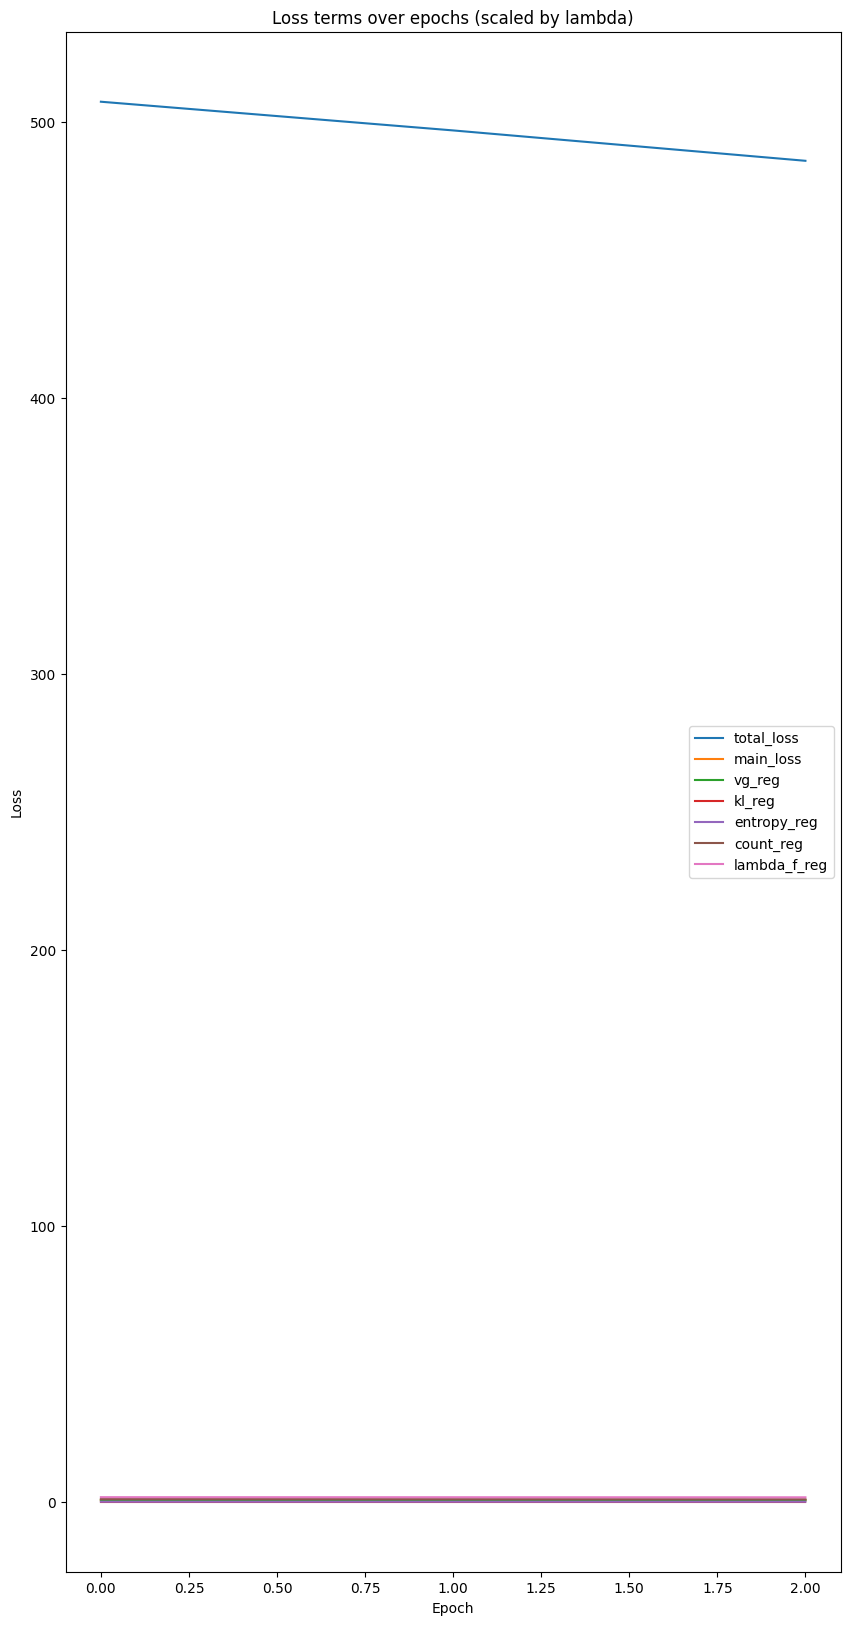

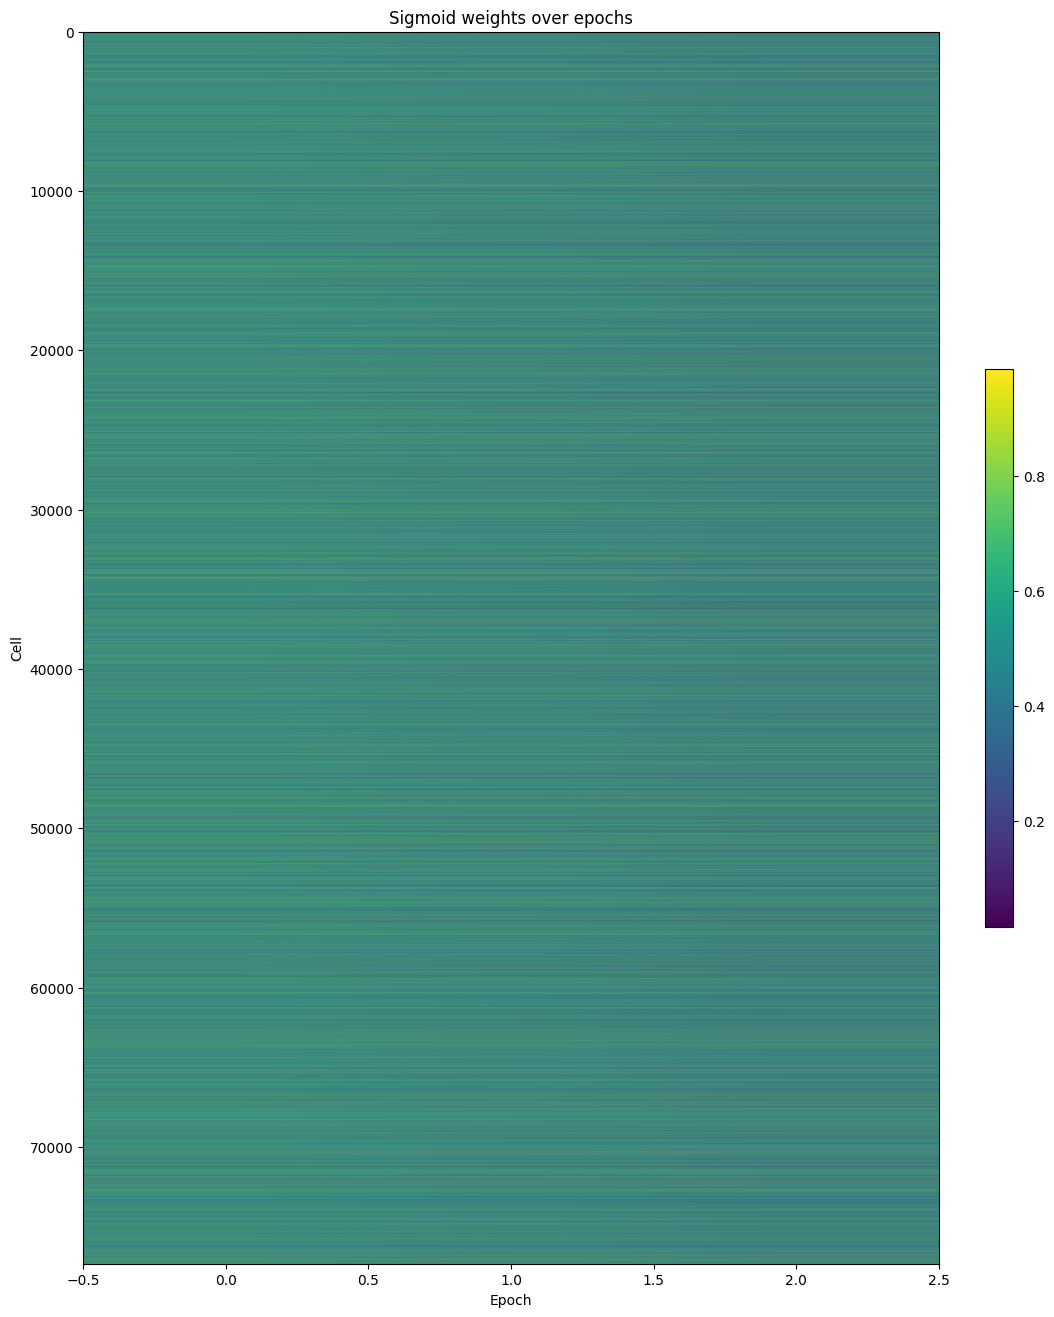

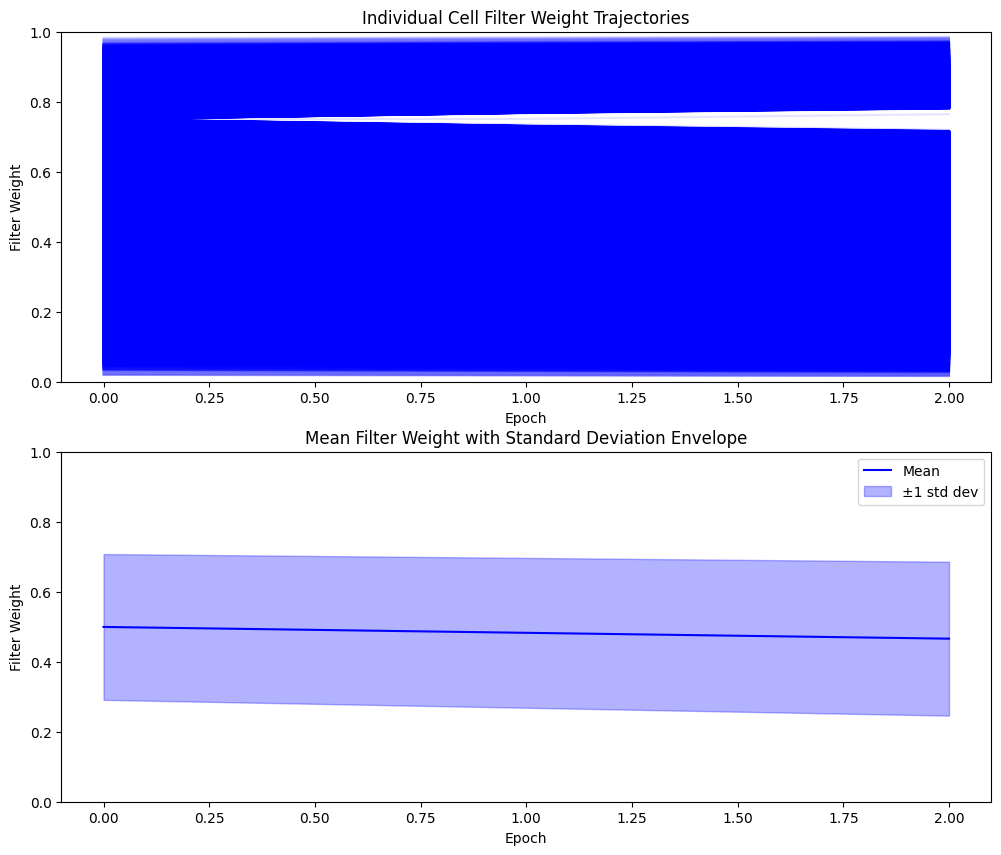

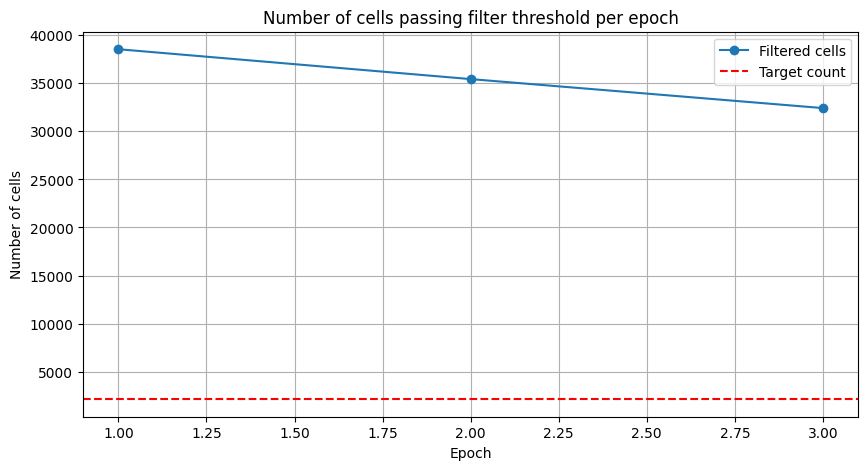

In [10]:
# Plot loss terms
tg.plot_loss_terms(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, log_scale=False)
tg.plot_loss_terms(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, log_scale=False, lambda_scale=True)

# Plot final filter values distribution
tg.plot_filter_weights_light(ad_map_filt, plot_spaghetti=True, plot_envelope=True)
tg.plot_filter_count(ad_map_filt, target_count=None)

In [14]:
ad_map_ref, _, _ = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='refined',
    num_epochs=30,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=0,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_sparsity_g1=1,
    lambda_neighborhood_g1=1,
    lambda_getis_ord=1,
    lambda_moran=1,
    lambda_geary=1,
    lambda_ct_islands=1,
    cluster_label='Allen.subclass_label',
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 164 M  | n/a  
---------------------------------------------------------
164 M     Trainable params
0         Non-trainable params
164 M     Total params
659.839   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


RuntimeError: [enforce fail at alloc_cpu.cpp:116] data. DefaultCPUAllocator: not enough memory: you tried to allocate 4586086512 bytes.

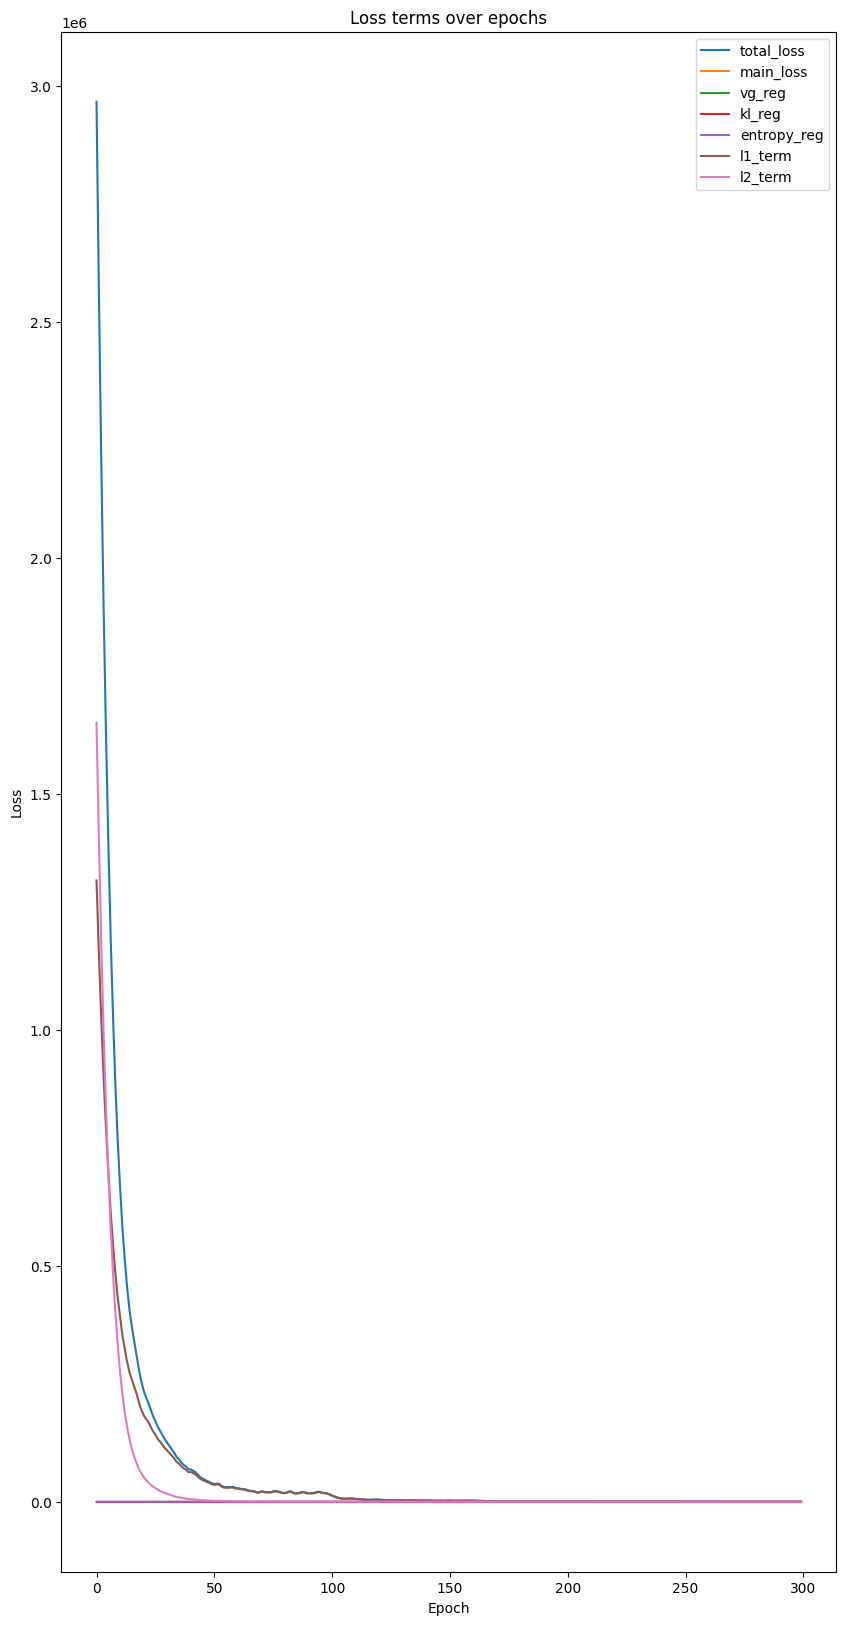

In [10]:
# Plot loss terms
tg.plot_loss_terms(adata_map=ad_map[0], log_scale=False)

# Optimization

## Regularization coefficients
Depending on the mode (cells or conrtained) the Tangram loss function has either up to 4 or up to 6 regularization coefficients. These coefficients scale (are multiplied to) each single term of the Loss and are quite necessary, since loss terms are defined heuristically and are not in the same order of magnitude by default. In fact quite the opposite is true: cosine similarity terms map into [-1, 1] by definition (and their mean as well), KL divergence is non-negative but with no upper bound, the entropy regularizer has no bound as well and filtering related terms are in the order of magnitude equal the number of target cells (i.e., number of spots).



For this reason, an initial set of coefficients that ensures all terms live approximately on the same scale is required. To do so, one can first run a naive unitary set and, based on visual inspection, retrieve the orders of magnitude and adjust accordingly. Alternatively, the values could be automatically set to match the order of magnitude of the terms in the first training step (as soon as the initial value of each term is available) and auto-adjust.

Subsequently, one can either turn off loss terms at will by assigning the corresponding coefficient a value of 0 or create a custom set based off of loss behaviour and mapping results.

### Baseline model

#### Cells mode

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 164 M  | n/a  
---------------------------------------------------------
164 M     Trainable params
0         Non-trainable params
164 M     Total params
659.839   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


`Trainer.fit` stopped: `max_epochs=30` reached.


Initial value of total_loss 4.51247501373291
Initial value of main_loss 0.5169236660003662
Initial value of vg_reg 0.5126924514770508
Initial value of kl_reg 1.1752592399716377e-05
Initial value of entropy_reg -5.542079448699951
Initial value of l1_term 0.0
Initial value of l2_term 0.0


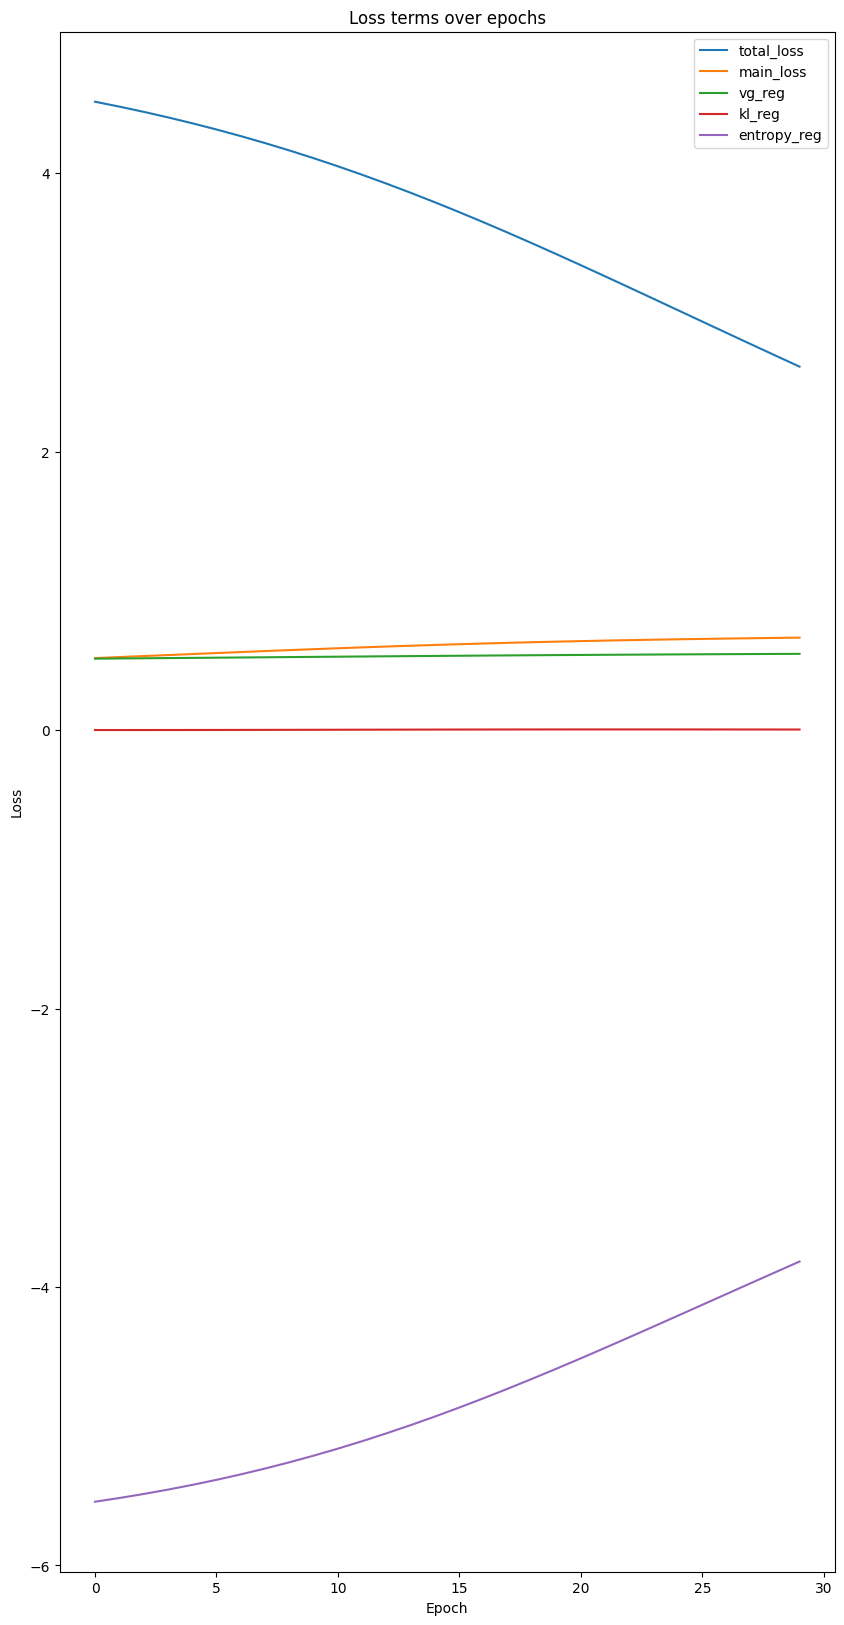

In [13]:
ad_map_baseline, _, _ = tg.map_cells_to_space(adata_sc, adata_st, 
                                mode='vanilla',
                                num_epochs=30,
                                lambda_d=1,
                                lambda_g1=1,
                                lambda_g2=1,
                                lambda_r=1e-5,
                                random_state=42,
                                )

# Plot loss terms
for term in ad_map_baseline.uns['training_history'].keys():
    value = ad_map_baseline.uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tg.plot_loss_terms(adata_map=ad_map_baseline, log_scale=False)

As we can see initial values are all over the place in terms of scale.

#### Constrained mode

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 252 genes and rna_count_based density_prior in constrained mode...


Regularizer coefficients:
lambda_d: 1, lambda_g1: 1, lambda_g2: 1, lambda_r: 1, lambda_count: 1, lambda_f_reg: 1, target_count: None


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Score: 0.354, VG reg: 0.356, KL reg: 0.081, Entropy reg: -701612.375, Count reg: 46759.570, Lambda f reg: 20226.395


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [05:05<00:00, 30.54s/it]
INFO:root:Saving results..


Initial value of total_loss 768597.6875
Initial value of main_loss 0.3536289930343628
Initial value of vg_reg 0.35632428526878357
Initial value of kl_reg 0.08081712573766708
Initial value of entropy_reg -701612.375
Initial value of count_reg 46759.5703125
Initial value of lambda_f_reg 20226.39453125


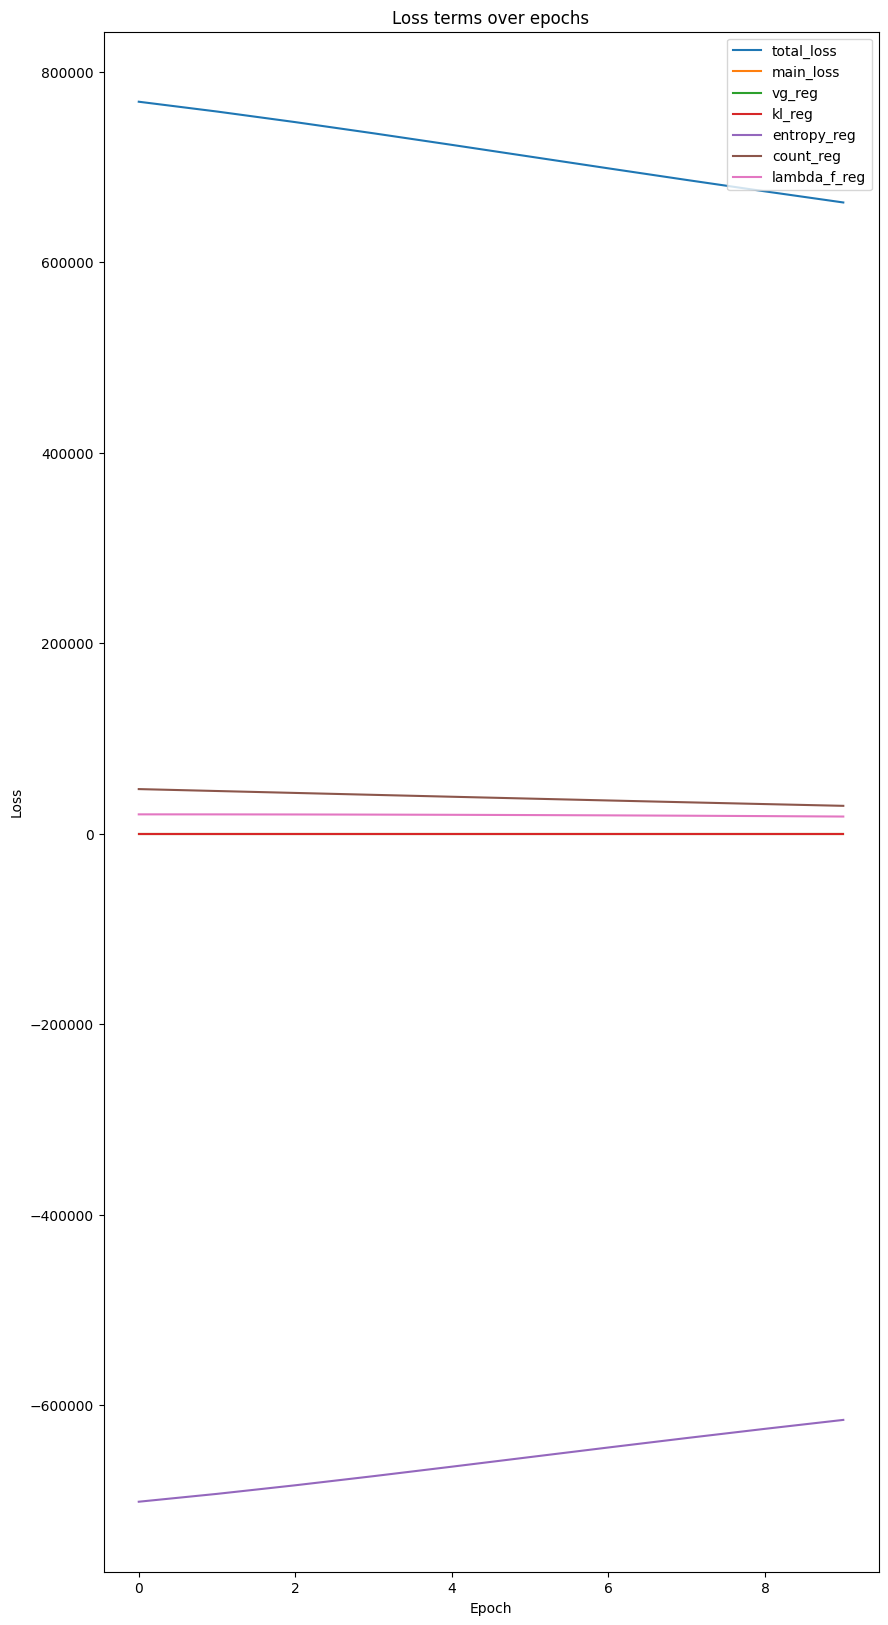

In [10]:
ad_map_baseline = tg.map_cells_to_space(adata_sc, adata_st, 
                                mode='constrained',
                                density_prior='rna_count_based', 
                                num_epochs=10,
                                lambda_d=1,
                                lambda_g1=1,
                                lambda_g2=1,
                                lambda_r=1,
                                lambda_count=1,
                                lambda_f_reg=1,
                                random_state=random_state,
                                )

# Plot loss terms
for term in ad_map_baseline.uns['training_history'].keys():
    value = ad_map_baseline.uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tg.plot_loss_terms(adata_map=ad_map_baseline, log_scale=False)

Same here with very distat scales. The entropy term is huge, but also filter terms are on a different scale.

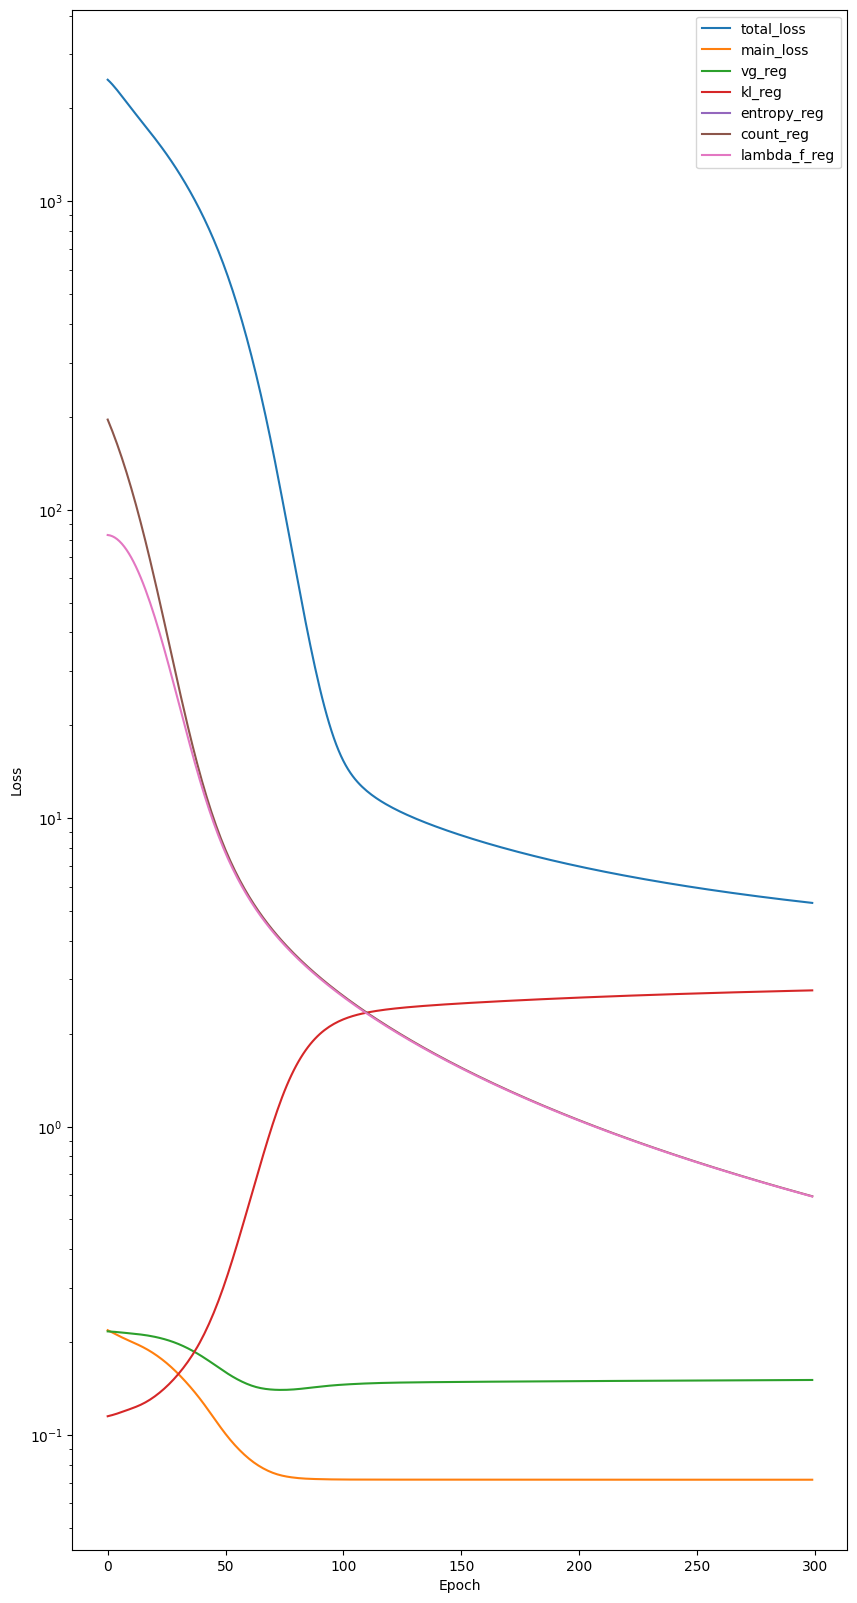

In [13]:
# Plot loss terms
tg.plot_loss_terms(adata_map=ad_map_baseline, log_scale=True)

This is the filtered mapper in 300 epochs (dont'recall the $\lambda$ values) in log scale. Again after 100 epochs values are settled, but scales are still off.

### Automatic coefficients
In this section we develop a function that automatically computes a suitable set of regularization hyperparameters, based on the scale of the existing input arguents to the mapping function.

* We know that all cosine similarity terms are, by definition, bounden in the $[-1, 1]$ interval and can possibly be shifted into $[0,2]$ by settig loss terms as $1-cossim()$. This would also turn the problem into a direct minimization instead of a negative maximization. Note that this is true because the loss terms are obtained as the average similarity over the rows/columns of the spatial matrices, alternatively one could use the sum, which would make the magnitude dependent on the input data size.

* The KL term has, by definition, a lower bound of 0 that is, ideally, approached during the optimization. The initial value depends on both the prior distribution d (usually uniform) and the starting estimate m, which depends on the IC for the matrix M. One can try to analytically extract an upper bound based on the initial estimated distribution.

* The entropy regularizer term is theoretically upper bounded by a uniform distribution over the values of M.

* The target count term initial value depends on the absolute number of cells in both datasets and the initial conditions of the filter. i.e. the expected value of the sum of its entries.

* The filter regularizer initial value can be described by a transformation of the expected value of the sum of the filter terms.

The problem is then to determine what is the optimal scale to move everything in: one could move all terms into the unitary ($10^0$) magnitude or a larger/smaller one. The core idea is that the order of magnitude affects losses absolute values and consequenlty all the gradient values. Ultimately, this affects the optimization only for basic algorithms that to not includean adaptive learning rate (like standard SDG), where the scale factor acts on the learning rate itself. Optimizers with an adaptive learning eate, like Adam,  are scale invariant so the problem is mitigated already.

## Cells sub-sampling
Here, we attempt to be reduce the number of observations in the sc data by dropping rare cell types and down-sampling the most abundant types, based on the histogram.

An initial criterion for down-sampling could be based on the signal quality/expression levels (keep only cells with a stronger signal), minding the potential risk of removing true zeros from the data.

An alternative is to run the algorithm at cluster level.

The clustering on sc data is a bit confusing:

In [ ]:
print('Number of clusters: ', adata_sc.obs['cluster'].nunique())
adata_sc.obs['cluster'].value_counts().sort_index().plot(kind='bar')

In [ ]:
print('Number of cluster ids: ', adata_sc.obs['Allen.cluster_id'].nunique())
print('Number of clusters labels: ', adata_sc.obs['Allen.cluster_label'].nunique())

In [ ]:
print('Number of cell classes: ', adata_sc.obs['Allen.class_label'].nunique())
print('Number of cell subclasses: ', adata_sc.obs['Allen.subclass_label'].nunique())

In [ ]:
print(adata_sc.obs['Allen.subclass_label'].unique())
adata_sc.obs['Allen.subclass_label'].value_counts().sort_index().plot(kind='bar')

## Loss behaviour and optimizers
I've noticed that with SGD no improvemnt in the loss is seen even after 200 epochs (completely stagnating gradient).

To further investigate it might be worth trying other initial condtions (perhaps base them on the final values that the M matrix with no softmax or filtering converges to and if they're coherent with the initial values).
Another aspect is the optimizer: ADAM works well, so first one can introduce momentum and see if it help escaping the flat zone quicker and secondly introduce adaptive learning rates and study theur behavior (how do they move in the loss landscape).

Anyhow, loss terms seem to have a pretty smooth trajectory with quite fast convergence when using ADAM.

The main reason why SGD might not work is that Tangram does not implement minibatches, as it learns the whole projection matrix at each training step, using all datapoints. This implies that the gradient is computed on the whole dataset with no effective stochastic component that usually ensures the optimizer to explore more rapidly the loss landscape. Adding momentum could help accelerate but an adaptive learning rate is clearly the best approach.

Another reason for adaptive learning rates is the scale problem mentioned above: with this approach the magnitued of the gradient is scaled automatically preventing large terms to overtake completely the gradient descent. The issue of scales persists only at the beginning, when Adam has not yet adjusted the scales.

Moreover, the loss function has terms that live on distinct parameter spaces, namely all filterm terms depend only on the filter entries $f$, while the entropy regularizer term depend only on the unfiltered (softmax) projection matrix $M$; together with terms that depend on the joint parameters space (filtered matrix $M$), namely the cosine similarities and the KL divergence.

This also argues in favor of a (single) adaptive optimizer as the best choice, as it can separate the learning process in the parameters sub-spaces.

## Initial conditions
As mentioned above, different ICs could change the outcome of a SDG based optimization.

Another thing that might be worth checking is if the IC of the filter affect its final values and, if so, how much. One way to see this is to check if the filter values of the cells that are "selected" at the end (have high confidence) correlate to ther initial values, i.e. if the initial values biases the selection. We can also compare to the correlation of all initial and final values pf the filter to see if there's some bias.

More in general, we could try different initialization approaches and see how the distribution type and parameters affect the optimization (e.g., can it affect sparsity of the $M$ matrix and so on).

# Lightning module
Here I just test the lightning module to see if it runs.

In [11]:
ad_map_lt = tg.map_cells_to_space_lightning(adata_sc, adata_st, mode=mode,
                                density_prior='rna_count_based', num_epochs=10,
                                lambda_d=1,
                                lambda_g1=0.5,
                                lambda_g2=0.5,
                                #lambda_r=0.0003,
                                #lambda_count=0.005,
                                #lambda_f_reg=0.01,
                                random_state=random_state,
                                )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
INFO:root:Using 252 training genes from adata.uns
INFO:root:Created dataset with 97766 cells, 2155 spots, and 252 genes

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 210 M  | n/a  
---------------------------------------------------------
210 M     Trainable params
0         Non-trainable params
210 M     Total params
842.743   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([1, 97766, 252])
G matrix shape: torch.Size([1, 2155, 252])


`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:root:Saving results..


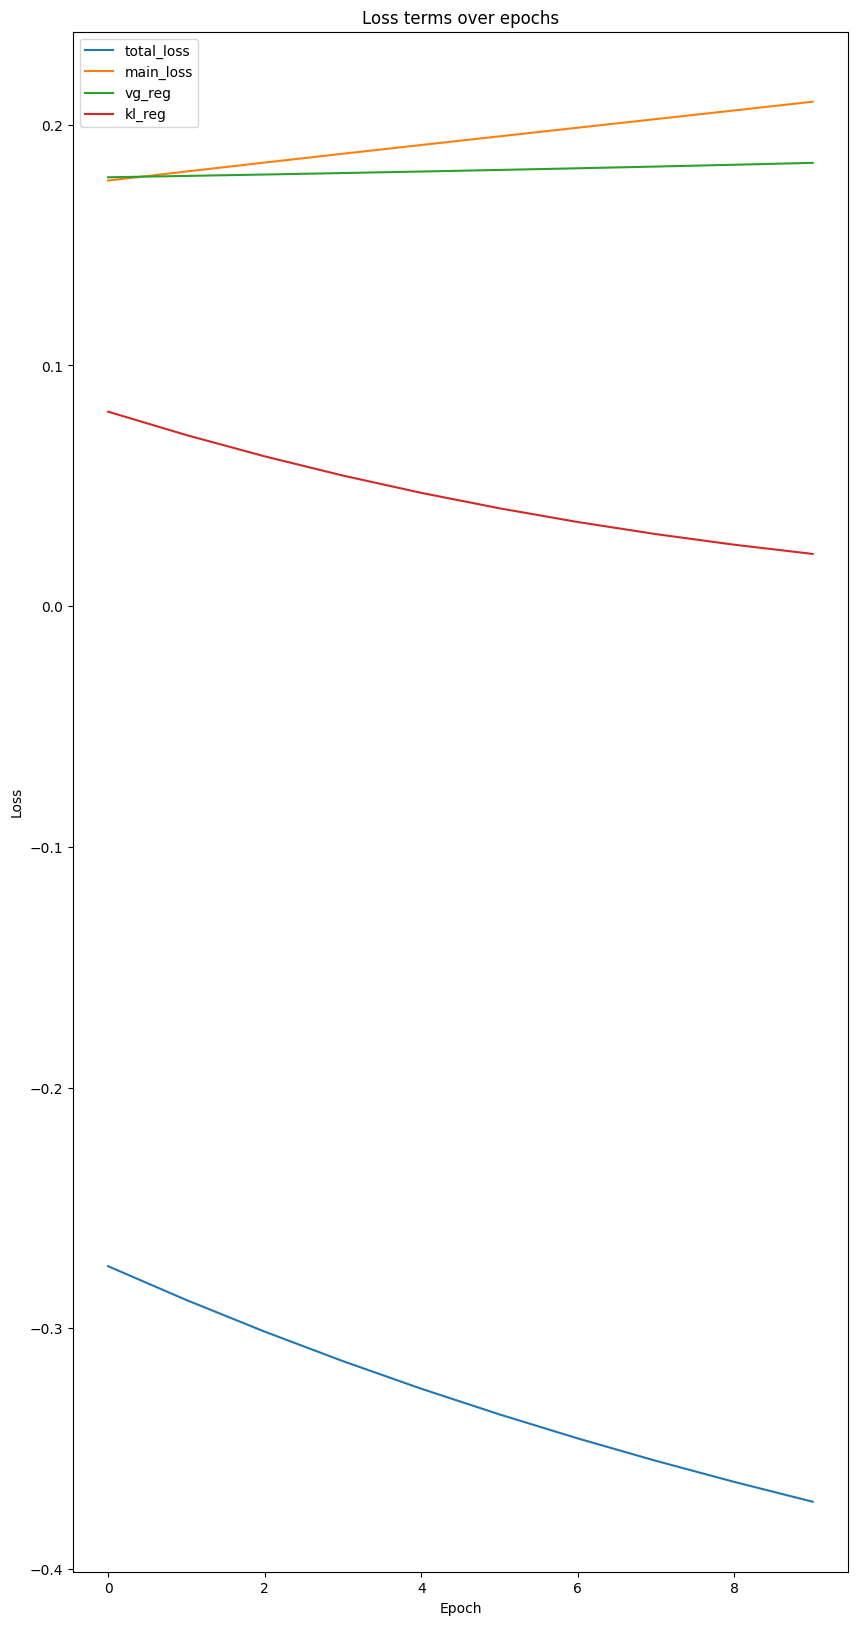

In [12]:
# Plot loss terms
tg.plot_loss_terms(adata_map=ad_map_lt, log_scale=False)

In [13]:
ad_map_lt_filt = tg.map_cells_to_space_lightning(adata_sc, adata_st, mode=mode,
                                density_prior='rna_count_based', num_epochs=10,
                                lambda_d=1,
                                lambda_g1=0.5,
                                lambda_g2=0.5,
                                lambda_r=0.03,
                                lambda_count=0.5,
                                lambda_f_reg=0.1,
                                random_state=random_state,
                                )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
INFO:root:Using 252 training genes from adata.uns
INFO:root:Created dataset with 97766 cells, 2155 spots, and 252 genes

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 210 M  | n/a  
---------------------------------------------------------
210 M     Trainable params
0         Non-trainable params
210 M     Total params
842.743   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training: |                                                                                      | 0/? [00:00<…

Training with 252 genes
S matrix shape: torch.Size([1, 97766, 252])
G matrix shape: torch.Size([1, 2155, 252])


`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:root:Saving results..


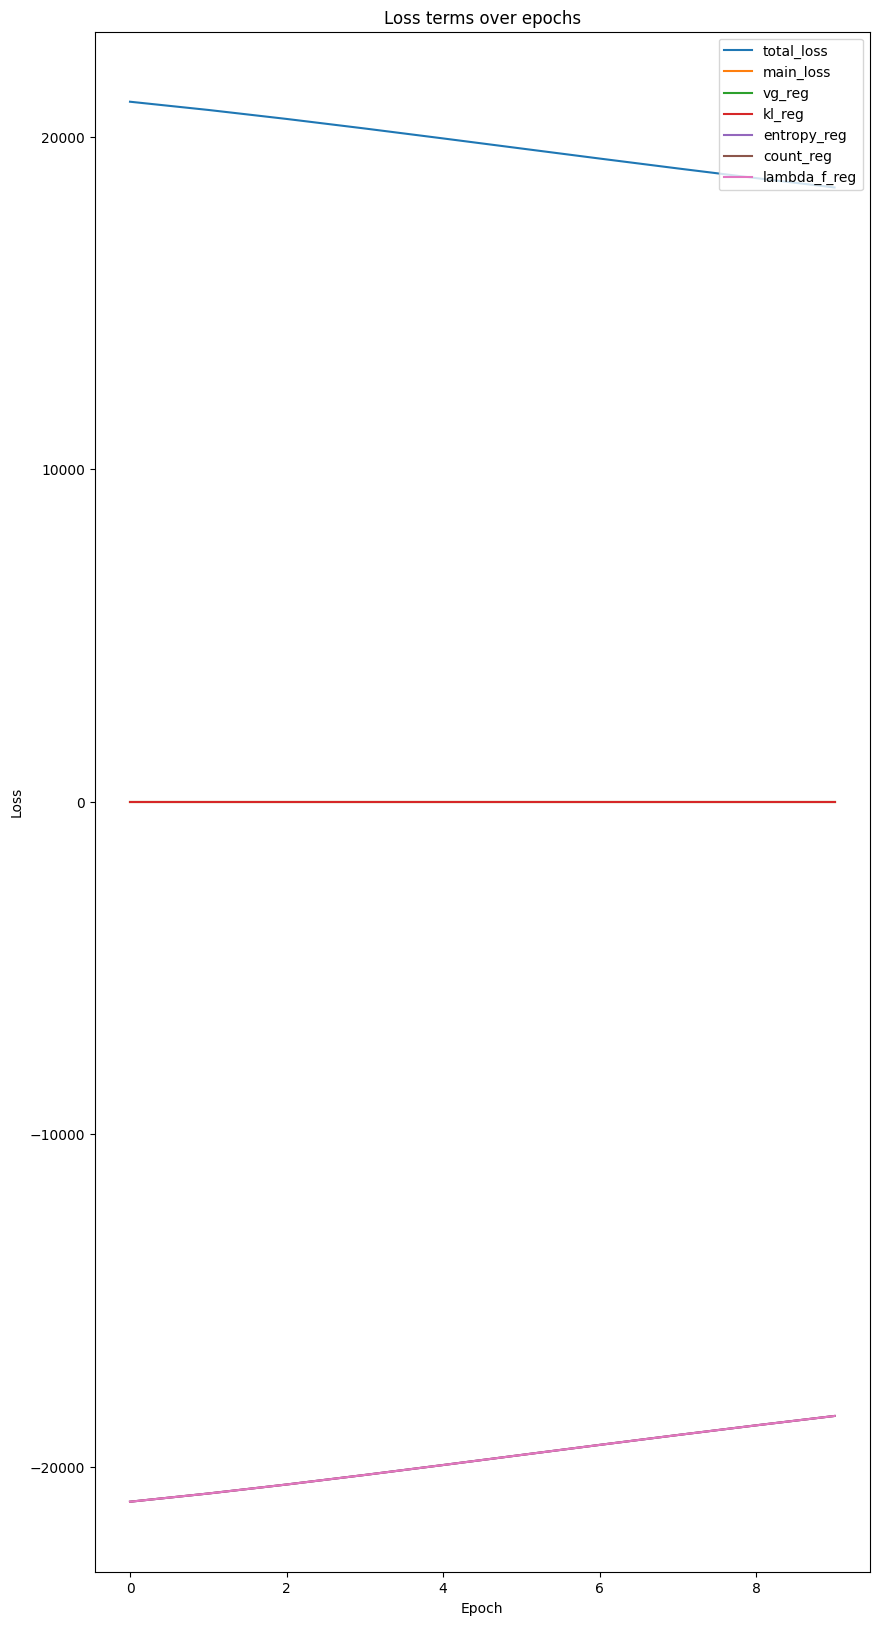

KeyError: 'filter_history'

In [15]:
# Plot loss terms
tg.plot_loss_terms(adata_map=ad_map_lt_filt, log_scale=False)

# Plot final filter values distribution
# if mode == "constrained":
tg.plot_filter_weights_light(ad_map_lt_filt, plot_spaghetti=True, plot_envelope=True)
tg.plot_filter_count(ad_map_lt_filt, target_count=target_count)